1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Raw Output: [[0.29910383 0.70089614]]
Prediction: non-defective
Confidence: 70.09 %


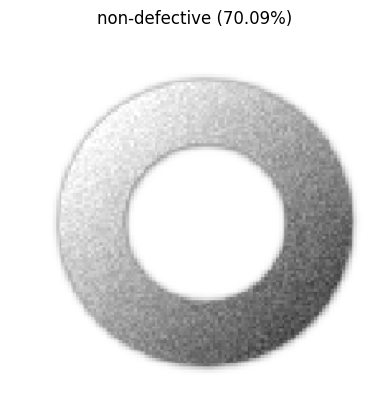

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt


model = load_model("washer_defect_model.keras")


labels = ['defective', 'non-defective']


img_path = r"C:\ml\washer_defect_predctor\non-def.png"  # change this


img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img)

# keep copy for display
display_img = img_array.astype("uint8")

img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)


pred = model.predict(img_array)

print("Raw Output:", pred)

idx = np.argmax(pred[0])
confidence = pred[0][idx] * 100

print("Prediction:", labels[idx])
print("Confidence:", round(confidence,2), "%")


plt.imshow(display_img.astype("uint8"))
plt.title(f"{labels[idx]} ({confidence:.2f}%)")
plt.axis("off")
plt.show()